## LIBRERIAS

In [ ]:
# =============================================================================
# LIBRERÍAS
# =============================================================================

import os
import shutil
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Input,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    silhouette_score
)
from sklearn.cluster import KMeans

import umap

warnings.filterwarnings('ignore')

In [ ]:
import random

## SETEAMOS SEMILLA

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED) ## ResNet50 , Inception , EfficientNetB2 , Transformer
# from tensorflow.keras.applications import DenseNet121,ResNet50,EfficientNetB0,Xception


## CARGAMOS LA BASE DE DATOS

In [ ]:
# Crear la carpeta .kaggle si no existe
os.makedirs("/root/.kaggle", exist_ok=True)
# Mover el archivo kaggle.json a la carpeta
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# Dar permisos adecuados
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d carloscanamejoy/dataset-spines-complete

Dataset URL: https://www.kaggle.com/datasets/carloscanamejoy/dataset-spines-complete
License(s): apache-2.0
100% 468M/468M [00:01<00:00, 294MB/s]



In [ ]:
# Nombre del archivo descargado (ajústalo según sea necesario)
dataset_zip = "/content/dataset-spines-complete.zip"
# Extraer los archivos
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall("dataset")
# Ver archivos extraídos
os.listdir("dataset")

['dataset-united.npz']

In [ ]:
file_ = '/content/dataset/dataset-united.npz'
data = np.load(file_)

print(data.files)

['img', 'params']


In [ ]:
data['img'].shape

(218256, 39, 39, 1)

In [ ]:
data['params'].shape

(218256, 8)

In [ ]:
X = np.copy(data['img'])
y = np.copy(data['params'])

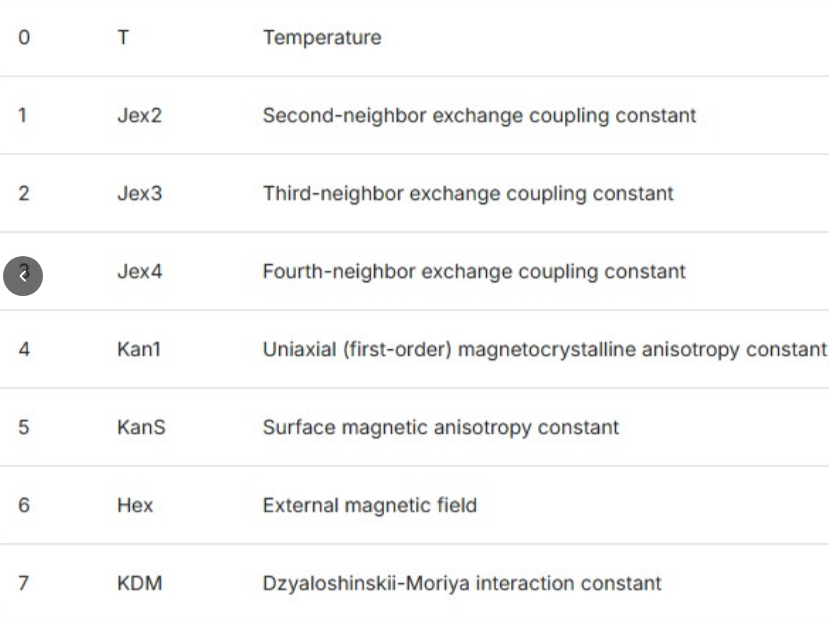

## DEFINIMOS SET DE TRAINING, VALIDACIÓN Y TEST

In [ ]:
from sklearn.model_selection import train_test_split

# test 15%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# validation 15% del total
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1765, random_state=42
)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

y_train_scaled = scaler.fit_transform(y_train)
y_val_scaled = scaler.transform(y_val)
y_test_scaled = scaler.transform(y_test)

In [ ]:
def preprocess_batch(x):
    x = tf.image.resize(x, (224,224))
    x = tf.image.grayscale_to_rgb(x)
    return x

In [ ]:
BATCH_SIZE = 512

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train_scaled))
    .shuffle(10000)
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

test_dataset = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test_scaled))
    .batch(BATCH_SIZE)
    .map(lambda x, y: (preprocess_batch(x), y),
         num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

## DEFINIMOS EL MODELO

In [ ]:
!pip install keras-hub

In [ ]:
import keras_hub
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model

# backbone
backbone = keras_hub.models.ViTBackbone.from_preset(
    "vit_base_patch16_224_imagenet"
)

inputs = tf.keras.Input(shape=(224,224,3))

x = backbone(inputs)

# colapsar tokens
x = GlobalAveragePooling1D()(x)

# regresión
outputs = Dense(8, activation="linear")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vi_t_backbone (ViTBackbone)     │ (None, 197, 768)       │    85,798,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         6,152 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,804,808 (327.32 MB)

 Trainable params: 85,804,808 (327.32 MB)

 Non-trainable params: 0 (0.00 B)

## ENTRENAMIENTO

In [ ]:
EPOCHS = 20

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-6
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 235s 649ms/step - loss: 0.0456 - mae: 0.1333 - val_loss: 0.0282 - val_mae: 0.1097 - learning_rate: 1.0000e-04
Epoch 2/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 558ms/step - loss: 0.0266 - mae: 0.1041 - val_loss: 0.0259 - val_mae: 0.1022 - learning_rate: 1.0000e-04
Epoch 3/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 558ms/step - loss: 0.0247 - mae: 0.0980 - val_loss: 0.0242 - val_mae: 0.0948 - learning_rate: 1.0000e-04
Epoch 4/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 558ms/step - loss: 0.0237 - mae: 0.0943 - val_loss: 0.0233 - val_mae: 0.0942 - learning_rate: 1.0000e-04
Epoch 5/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 556ms/step - loss: 0.0229 - mae: 0.0920 - val_loss: 0.0239 - val_mae: 0.0954 - learning_rate: 1.0000e-04
Epoch 6/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 559ms/step - loss: 0.0223 - mae: 0.0902 - val_loss: 0.0226 - val_mae: 0.0906 - learning_rate: 1.0000e-04
Epoch 7/20
299/299 ━━━━━━━━━━━━━━━━━━━━ 167s 557ms/step - loss: 0.0217 - mae: 0.0882 - val_loss: 0.0

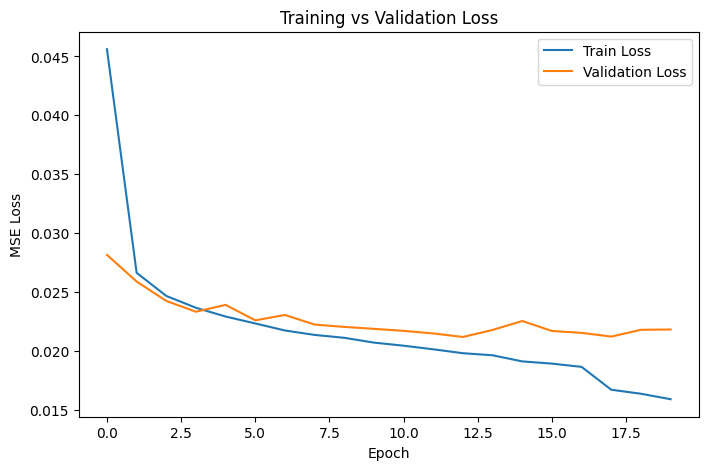

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

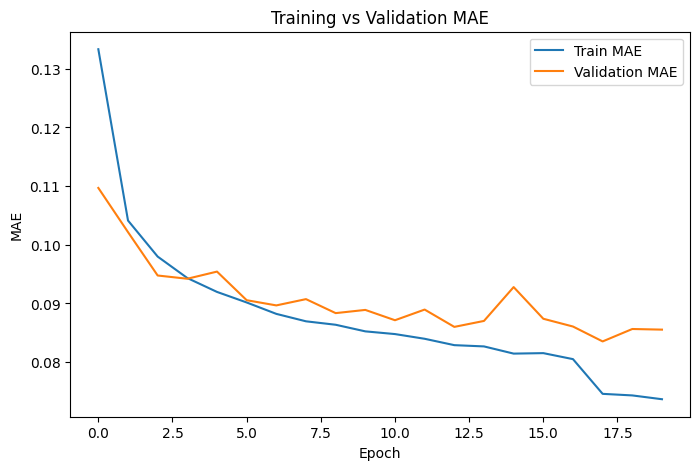

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Training vs Validation MAE")
plt.legend()

plt.show()

## GUARDAMOS LOS PESOS

In [ ]:
model.save('/content/drive/MyDrive/DoctoradoPaper1/modelo_Vit_fulldatabaseV2.h5')

In [ ]:
model.save('/content/drive/MyDrive/DoctoradoPaper1/modelo_Vit_fulldatabaseV2.keras')

## EVALUAMOS RENDIMIENTO

In [ ]:
y_pred_scaled = model.predict(test_dataset)

# regresar a escala original
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test_scaled)

64/64 ━━━━━━━━━━━━━━━━━━━━ 19s 244ms/step


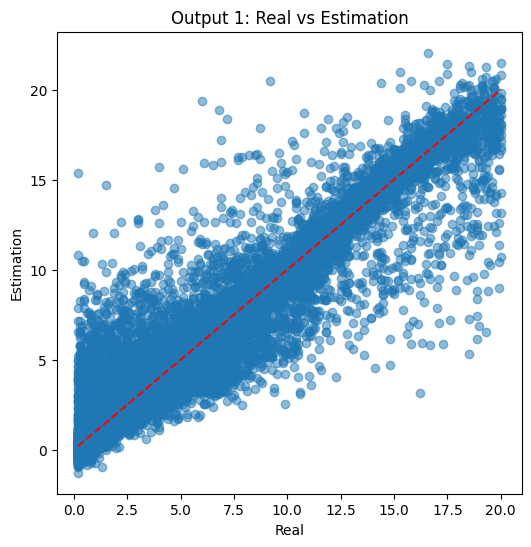

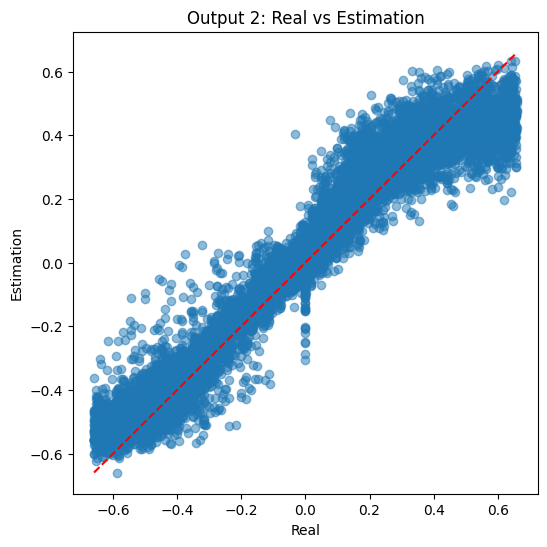

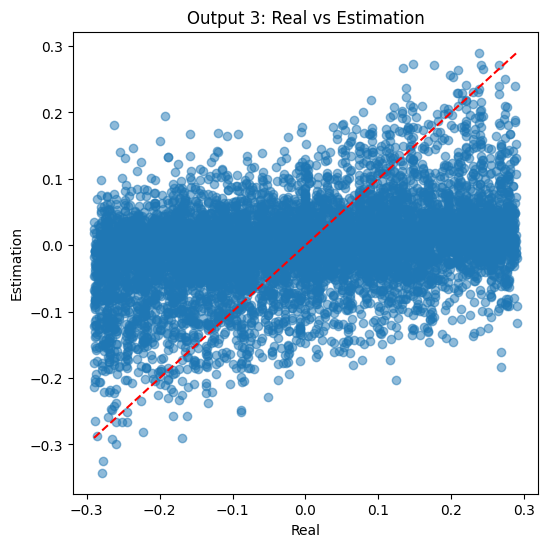

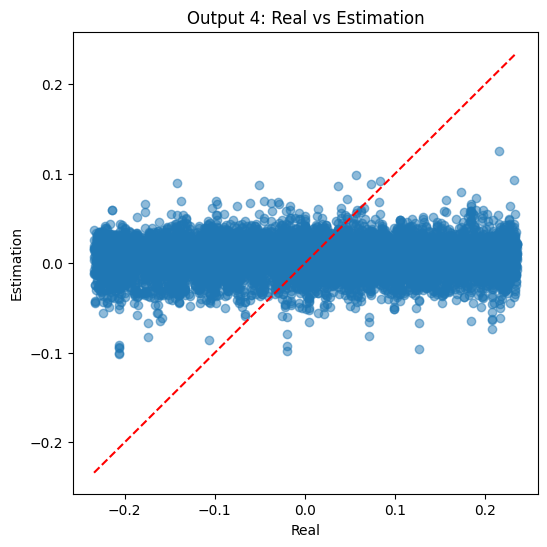

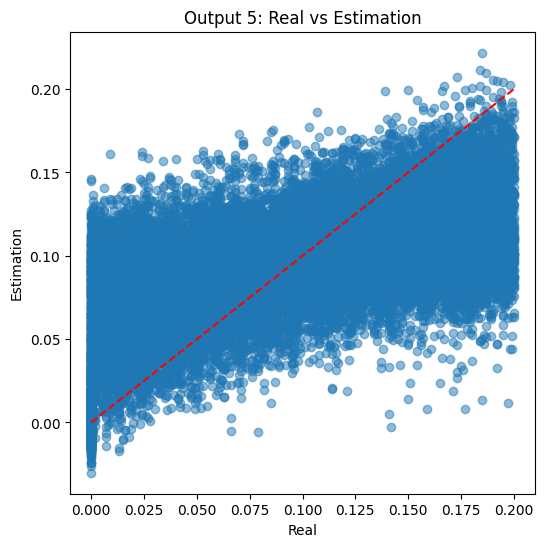

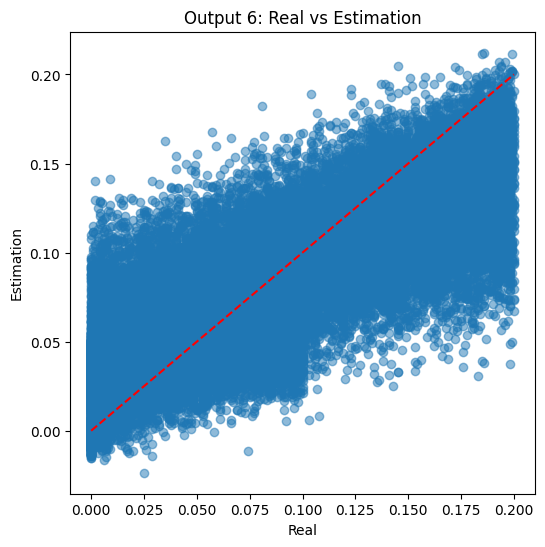

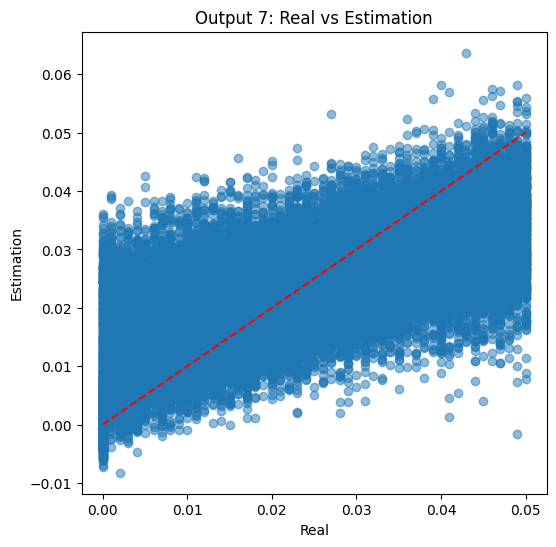

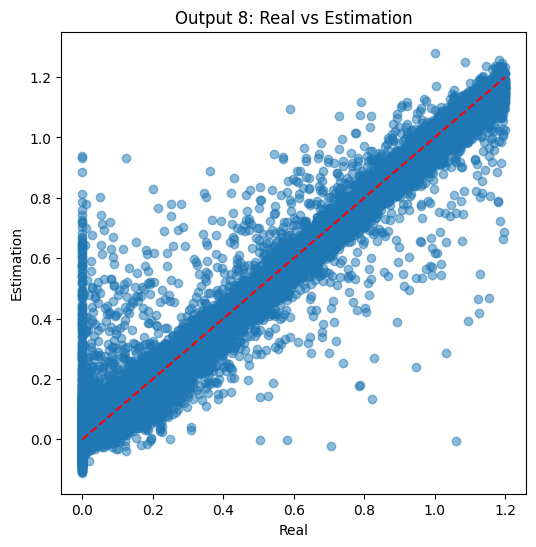

In [ ]:
import matplotlib.pyplot as plt

n_outputs = y_true.shape[1]

for i in range(n_outputs):

    plt.figure(figsize=(6,6))

    plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.5)

    plt.plot(
        [y_true[:, i].min(), y_true[:, i].max()],
        [y_true[:, i].min(), y_true[:, i].max()],
        'r--'
    )

    plt.xlabel("Real")
    plt.ylabel("Estimation")
    plt.title(f"Output {i+1}: Real vs Estimation")

    plt.show()

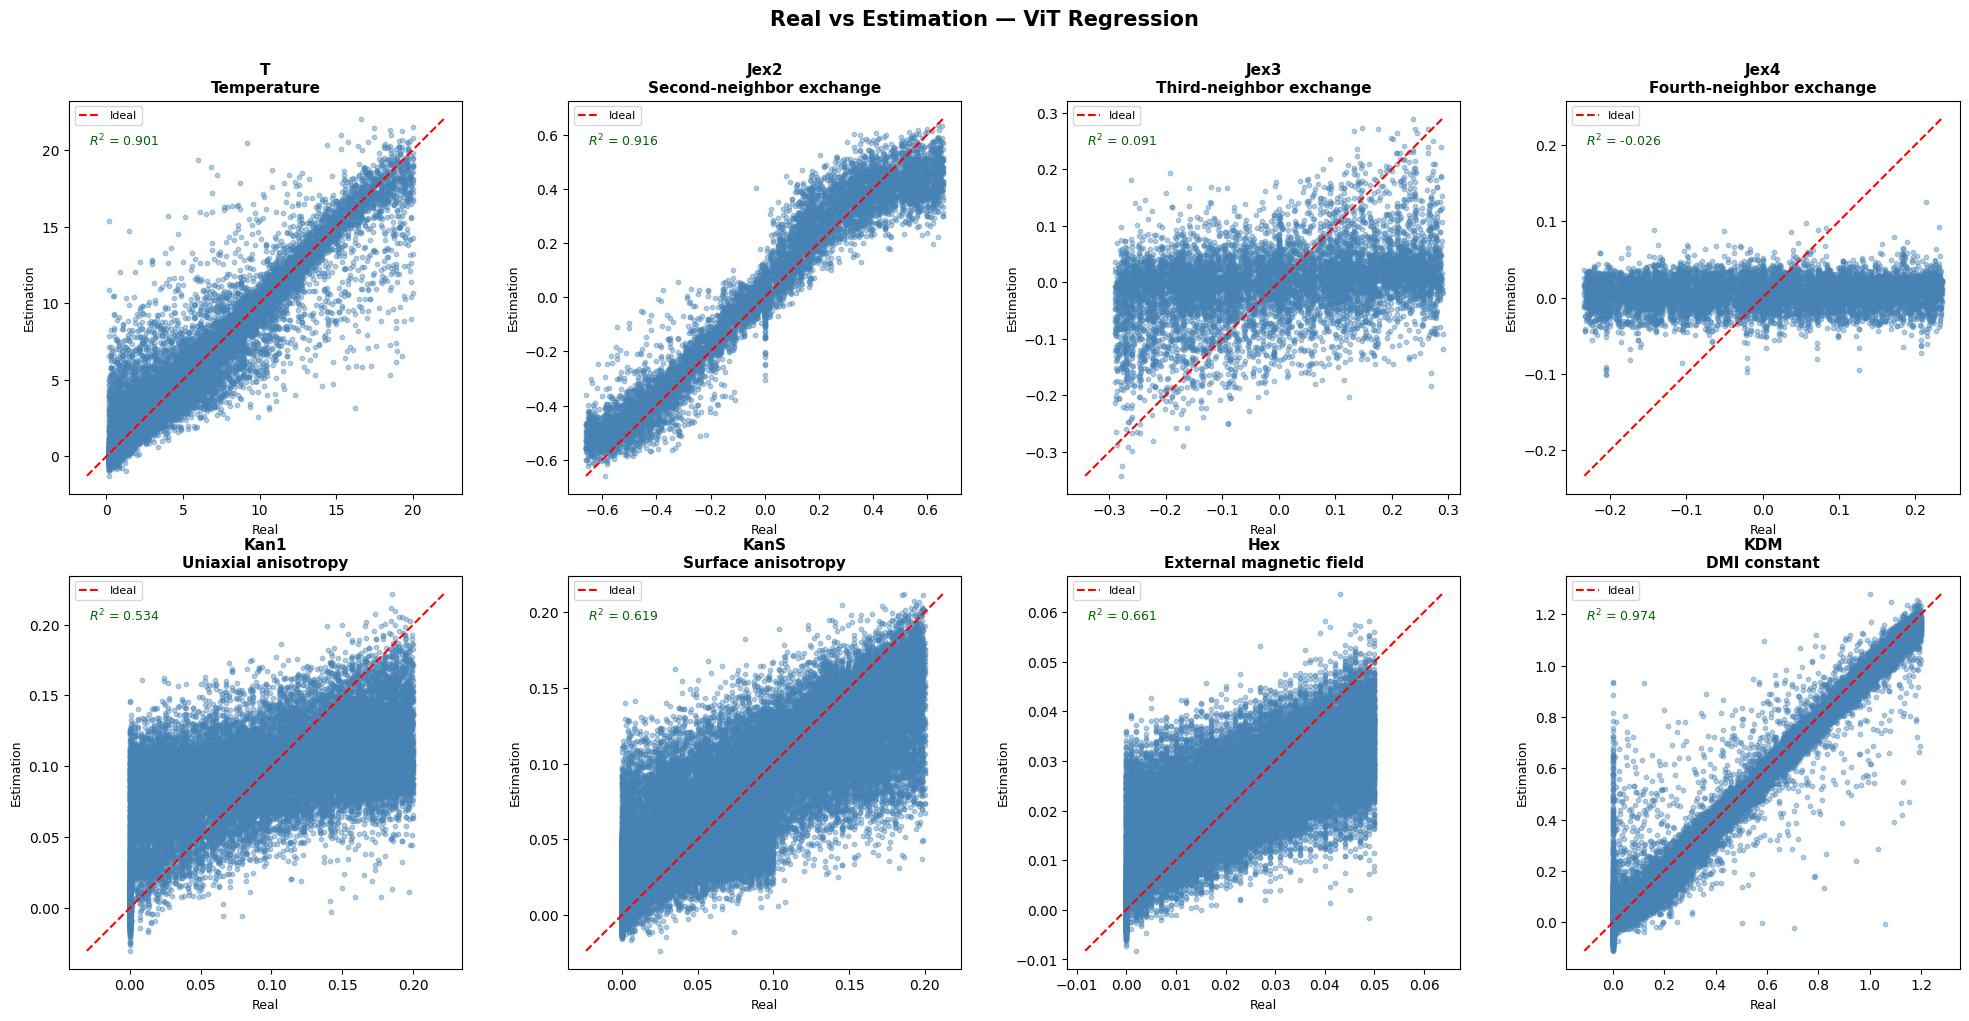

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]
descriptions = [
    "Temperature",
    "Second-neighbor exchange",
    "Third-neighbor exchange",
    "Fourth-neighbor exchange",
    "Uniaxial anisotropy",
    "Surface anisotropy",
    "External magnetic field",
    "DMI constant"
]

n_outputs = y_true.shape[1]
n_cols = 4
n_rows = int(np.ceil(n_outputs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i in range(n_outputs):
    ax = axes[i]

    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.4, s=10, color="steelblue")

    lims = [
        min(y_true[:, i].min(), y_pred[:, i].min()),
        max(y_true[:, i].max(), y_pred[:, i].max())
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label="Ideal")

    # R² por output
    ss_res = np.sum((y_true[:, i] - y_pred[:, i]) ** 2)
    ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    ax.set_title(f"{param_names[i]}\n{descriptions[i]}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Real", fontsize=9)
    ax.set_ylabel("Estimation", fontsize=9)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f"$R^2$ = {r2:.3f}", transform=ax.transAxes,
            fontsize=9, color="darkgreen", verticalalignment='top')
    ax.set_aspect('equal', 'box')

# ocultar ejes sobrantes si n_outputs < n_cols * n_rows
for j in range(n_outputs, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Real vs Estimation — ViT Regression", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("vit_predictions_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## CALCULAMOS METRICAS DE RENDIMIENTO

casi que el mejor modelo en este caso


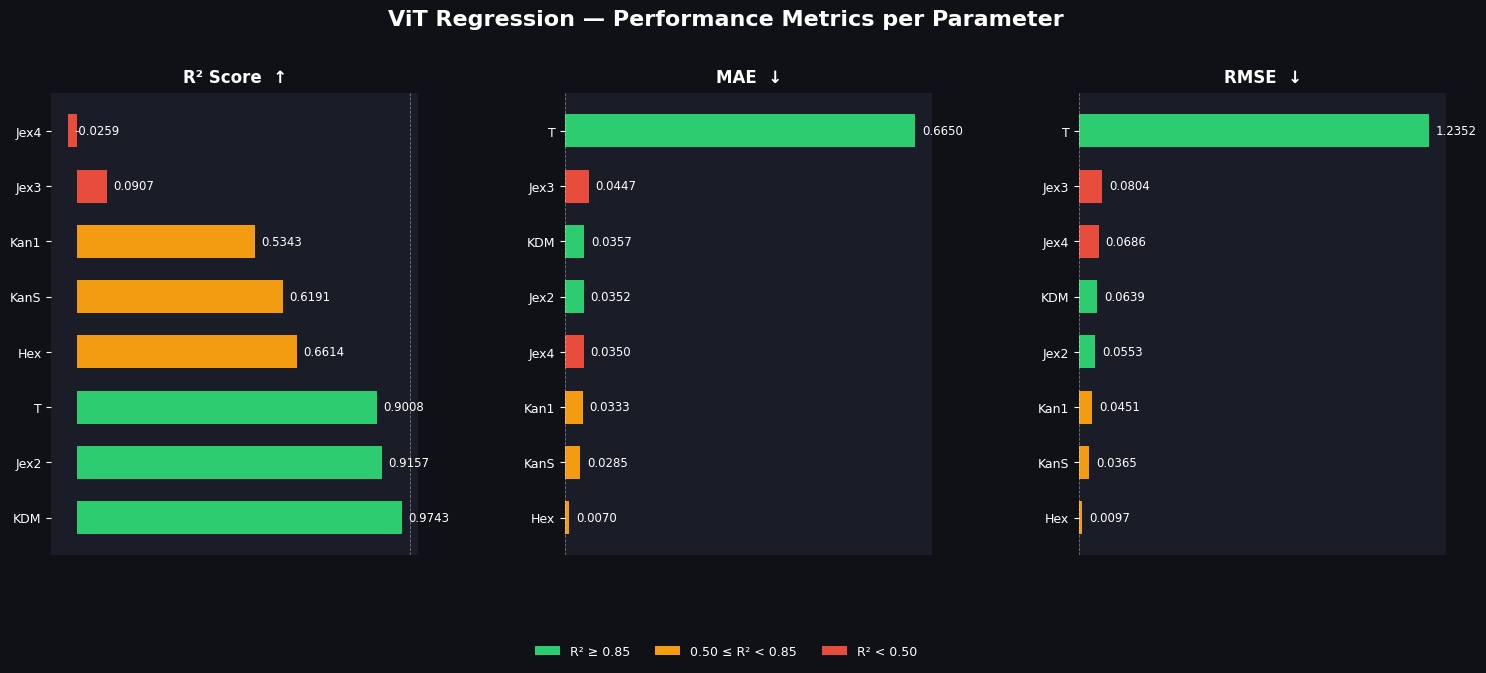

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

def get_color(r2):
    if r2 >= 0.85:   return "#2ecc71"
    elif r2 >= 0.5:  return "#f39c12"
    else:            return "#e74c3c"

colors = [get_color(df_metrics.loc[p, "R²"]) for p in param_names]

fig = plt.figure(figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("ViT Regression — Performance Metrics per Parameter",
             fontsize=16, fontweight="bold", color="white", y=1.02)

metrics = ["R²", "MAE", "RMSE"]
titles  = ["R² Score  ↑", "MAE  ↓", "RMSE  ↓"]

gs = gridspec.GridSpec(1, 3, wspace=0.4)

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor("#1a1d27")

    values = [df_metrics.loc[p, metric] for p in param_names]

    order = np.argsort(values)[::-1] if metric == "R²" else np.argsort(values)

    sorted_params = [param_names[i] for i in order]
    sorted_values = [values[i]      for i in order]
    sorted_colors = [colors[i]      for i in order]

    bars = ax.barh(sorted_params, sorted_values,
                   color=sorted_colors, edgecolor="none", height=0.6)

    ref = 1.0 if metric == "R²" else 0.0
    ax.axvline(ref, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

    for bar, val in zip(bars, sorted_values):
        ax.text(bar.get_width() + max(abs(v) for v in sorted_values) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left",
                color="white", fontsize=8.5)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=8)
    ax.tick_params(colors="white", labelsize=9)
    ax.spines[:].set_visible(False)
    ax.xaxis.set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="R² ≥ 0.85"),
    Patch(facecolor="#f39c12", label="0.50 ≤ R² < 0.85"),
    Patch(facecolor="#e74c3c", label="R² < 0.50"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           frameon=False, fontsize=9,
           labelcolor="white", bbox_to_anchor=(0.5, -0.08))

plt.savefig("vit_metrics_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## REVISIÓN PARAMETROS

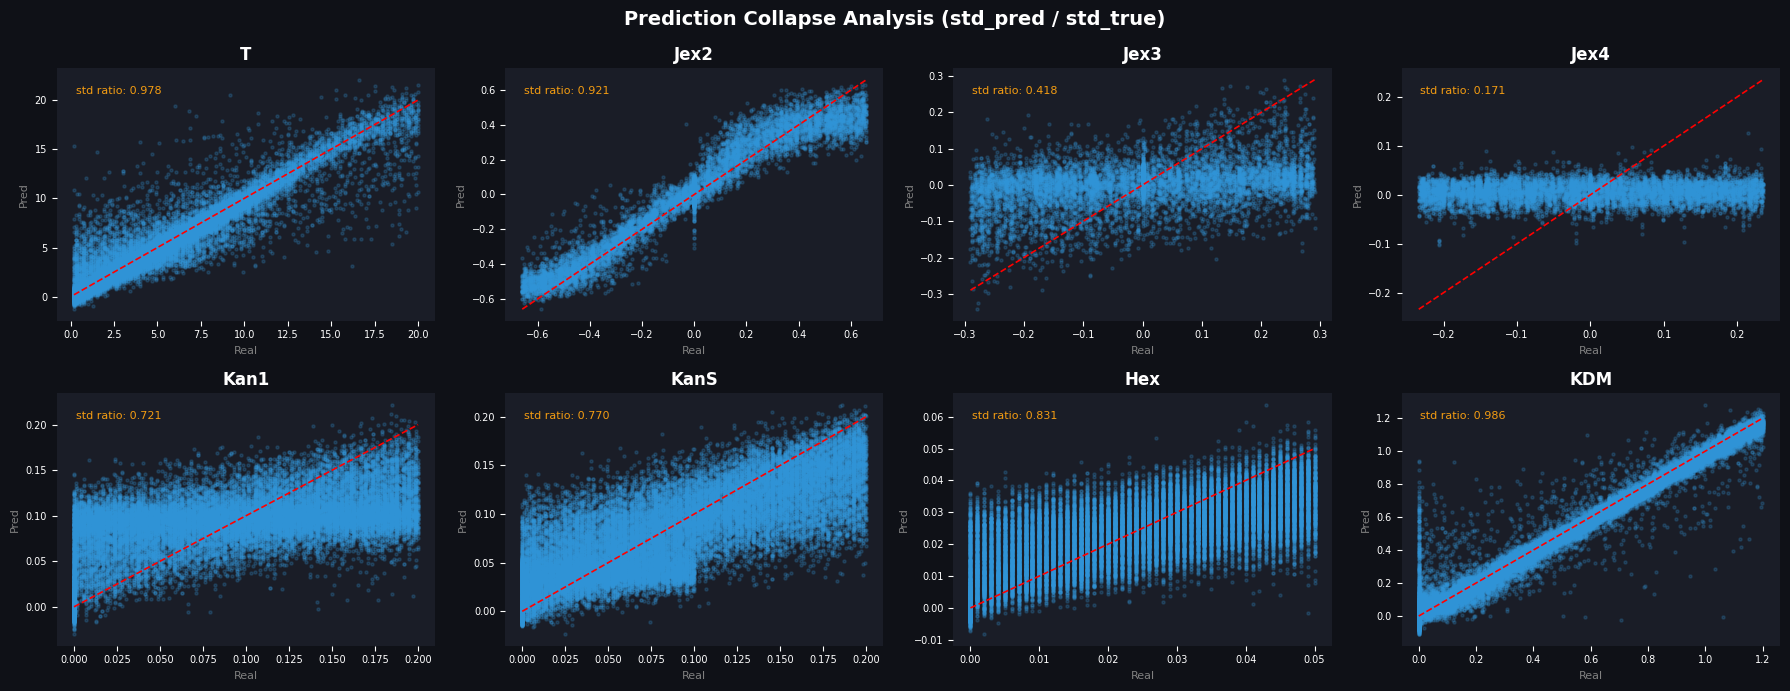

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor="#0f1117")
axes = axes.flatten()

for i, (name, ax) in enumerate(zip(param_names, axes)):
    ax.set_facecolor("#1a1d27")

    std_pred = y_pred[:, i].std()
    std_true = y_true[:, i].std()
    ratio    = std_pred / std_true  # si ≈ 0 → el modelo predice casi constante

    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.2, s=5, color="#3498db")
    lims = [y_true[:, i].min(), y_true[:, i].max()]
    ax.plot(lims, lims, 'r--', linewidth=1.2)

    ax.set_title(name, color="white", fontweight="bold")
    ax.text(0.05, 0.90, f"std ratio: {ratio:.3f}", transform=ax.transAxes,
            color="#f39c12", fontsize=8)
    ax.tick_params(colors="white", labelsize=7)
    ax.spines[:].set_visible(False)
    ax.set_xlabel("Real", color="gray", fontsize=8)
    ax.set_ylabel("Pred", color="gray", fontsize=8)

fig.suptitle("Prediction Collapse Analysis (std_pred / std_true)", color="white",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("collapse.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

## DATA

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

def get_color(r2):
    if r2 >= 0.85:   return "#2ecc71"
    elif r2 >= 0.5:  return "#f39c12"
    else:            return "#e74c3c"

colors = [get_color(df_metrics.loc[p, "R²"]) for p in param_names]

fig = plt.figure(figsize=(18, 6), facecolor="#0f1117")
fig.suptitle("ViT Regression — Performance Metrics per Parameter",
             fontsize=16, fontweight="bold", color="white", y=1.02)

metrics = ["R²", "MAE", "RMSE"]
titles  = ["R² Score  ↑", "MAE  ↓", "RMSE  ↓"]

gs = gridspec.GridSpec(1, 3, wspace=0.4)

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor("#1a1d27")

    values = [df_metrics.loc[p, metric] for p in param_names]

    order = np.argsort(values)[::-1] if metric == "R²" else np.argsort(values)

    sorted_params = [param_names[i] for i in order]
    sorted_values = [values[i]      for i in order]
    sorted_colors = [colors[i]      for i in order]

    bars = ax.barh(sorted_params, sorted_values,
                   color=sorted_colors, edgecolor="none", height=0.6)

    ref = 1.0 if metric == "R²" else 0.0
    ax.axvline(ref, color="white", linewidth=0.6, linestyle="--", alpha=0.4)

    for bar, val in zip(bars, sorted_values):
        ax.text(bar.get_width() + max(abs(v) for v in sorted_values) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", ha="left",
                color="white", fontsize=8.5)

    ax.set_title(title, color="white", fontsize=12, fontweight="bold", pad=8)
    ax.tick_params(colors="white", labelsize=9)
    ax.spines[:].set_visible(False)
    ax.xaxis.set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2ecc71", label="R² ≥ 0.85"),
    Patch(facecolor="#f39c12", label="0.50 ≤ R² < 0.85"),
    Patch(facecolor="#e74c3c", label="R² < 0.50"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           frameon=False, fontsize=9,
           labelcolor="white", bbox_to_anchor=(0.5, -0.08))

plt.savefig("vit_metrics_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

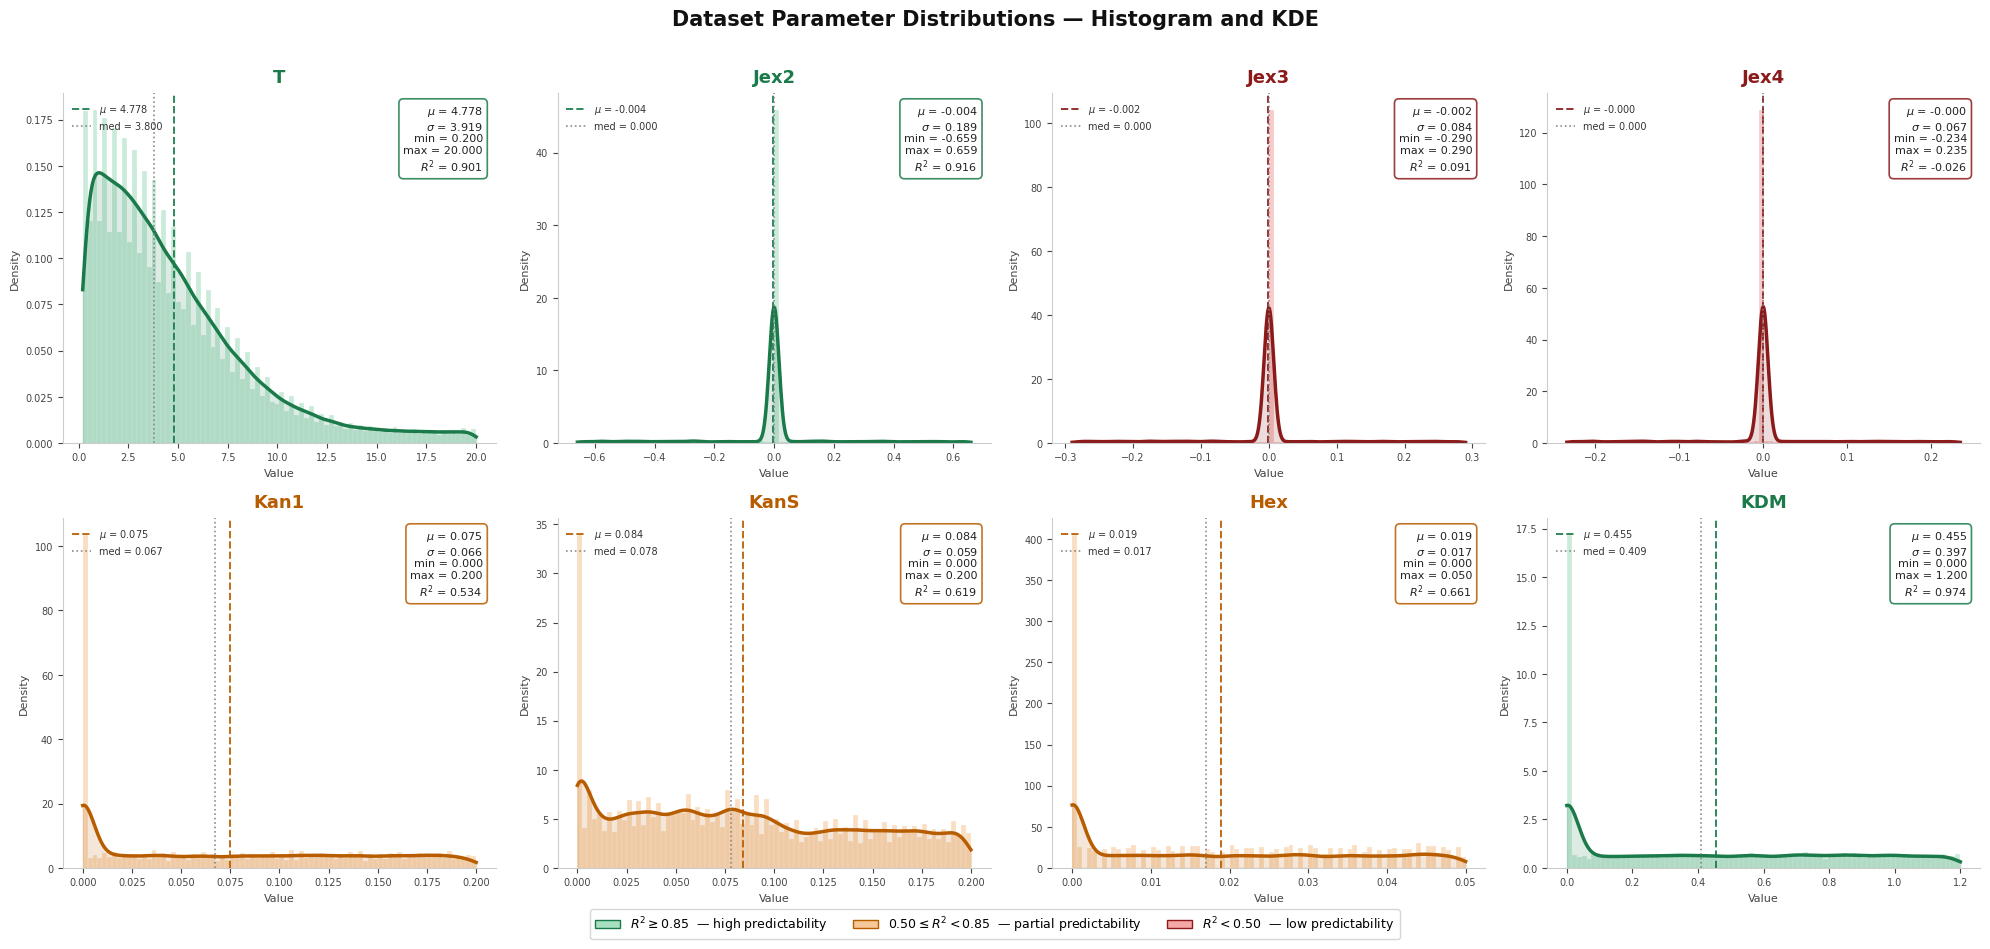

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

param_names = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9), facecolor="white")
axes = axes.flatten()

r2_vals = [df_metrics.loc[p, "R²"] for p in param_names]

# paleta discreta por nivel de R²
def get_colors(r2):
    if r2 >= 0.85:  return "#1a7a4a", "#a8dfc0"   # verde oscuro, verde claro
    elif r2 >= 0.5: return "#b85c00", "#f5c89a"   # naranja oscuro, naranja claro
    else:           return "#8b1a1a", "#f5a8a8"   # rojo oscuro, rojo claro

for i, (name, ax) in enumerate(zip(param_names, axes)):
    ax.set_facecolor("white")

    data        = y[:, i]
    c_line, c_fill = get_colors(r2_vals[i])

    # histograma
    ax.hist(data, bins=80, density=True,
            color=c_fill, alpha=0.6, edgecolor="white", linewidth=0.3)

    # KDE
    kde    = gaussian_kde(data, bw_method="scott")
    x_grid = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_grid, kde(x_grid), color=c_line, linewidth=2.5)

    # relleno bajo la curva
    ax.fill_between(x_grid, kde(x_grid), alpha=0.15, color=c_line)

    # líneas estadísticos
    ax.axvline(data.mean(), color=c_line, linewidth=1.4,
               linestyle="--", alpha=0.9, label=f"$\\mu$ = {data.mean():.3f}")
    ax.axvline(np.median(data), color="gray", linewidth=1.2,
               linestyle=":", alpha=0.9, label=f"med = {np.median(data):.3f}")

    # caja de stats
    stats_text = (f"$\\mu$ = {data.mean():.3f}\n"
                  f"$\\sigma$ = {data.std():.3f}\n"
                  f"min = {data.min():.3f}\n"
                  f"max = {data.max():.3f}\n"
                  f"$R^2$ = {r2_vals[i]:.3f}")
    ax.text(0.97, 0.97, stats_text,
            transform=ax.transAxes, fontsize=8,
            color="#222222", va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.4",
                      facecolor="white", alpha=0.85,
                      edgecolor=c_line, linewidth=1.2))

    ax.set_title(name, color=c_line, fontsize=13, fontweight="bold", pad=8)
    ax.set_ylabel("Density", color="#444444", fontsize=8)
    ax.set_xlabel("Value", color="#444444", fontsize=8)
    ax.tick_params(colors="#444444", labelsize=7)

    # solo bordes izquierdo e inferior
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")

    ax.legend(frameon=False, fontsize=7,
              labelcolor="#333333", loc="upper left")

# leyenda global de colores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#a8dfc0", edgecolor="#1a7a4a", label="$R^2 \\geq 0.85$  — high predictability"),
    Patch(facecolor="#f5c89a", edgecolor="#b85c00", label="$0.50 \\leq R^2 < 0.85$  — partial predictability"),
    Patch(facecolor="#f5a8a8", edgecolor="#8b1a1a", label="$R^2 < 0.50$  — low predictability"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           frameon=True, fontsize=9, fancybox=True,
           edgecolor="#cccccc", bbox_to_anchor=(0.5, -0.03))

fig.suptitle("Dataset Parameter Distributions — Histogram and KDE",
             fontsize=15, fontweight="bold", color="#111111", y=1.01)

plt.tight_layout()
plt.savefig("distributions_paper.png", dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()